In [5]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict

In [6]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    six: int

    strike_rate: float
    balls_per_boundary: float
    boundary_percent: float
    summary: str

In [13]:
def calculate_strike_rate(state: BatsmanState) -> BatsmanState:
    if state['balls'] == 0:
        strike_rate = 0.0
    else:
        strike_rate = (state['runs'] / state['balls']) * 100
    return {"strike_rate": strike_rate}

def calculate_balls_per_boundary(state: BatsmanState) -> BatsmanState:
    total_boundaries = state['fours'] + state['six']
    if total_boundaries == 0:
        balls_per_boundary = float('inf')  # No boundaries, infinite balls per boundary
    else:
        balls_per_boundary = state['balls'] / total_boundaries
    return {"balls_per_boundary": balls_per_boundary}

def boundary_percent(state: BatsmanState) -> BatsmanState:
    if state['balls'] == 0:
        boundary_percent = 0.0
    else:
        total_boundaries = state['fours'] + state['six']
        boundary_percent = (total_boundaries / state['balls']) * 100
    return {"boundary_percent": boundary_percent}

def summary(state: BatsmanState) -> BatsmanState:
    summary = (f"Runs: {state['runs']}, "
               f"Balls: {state['balls']}, "
               f"Fours: {state['fours']}, "
               f"Sixes: {state['six']}, "
               f"Strike Rate: {state['strike_rate']:.2f}%, "
               f"Balls per Boundary: {state['balls_per_boundary']:.2f}, "
               f"Boundary Percent: {state['boundary_percent']:.2f}%")
    return {"summary": summary}

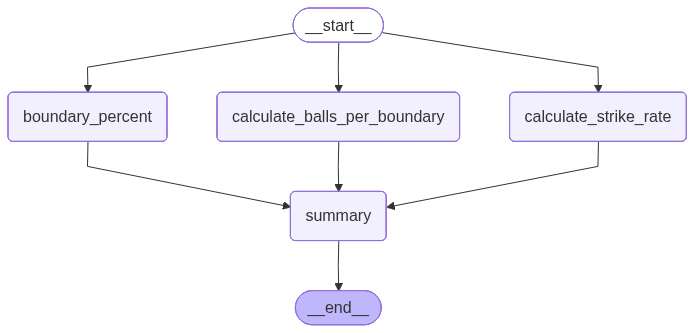

In [14]:
graph = StateGraph(BatsmanState)

graph.add_node("calculate_strike_rate", calculate_strike_rate)
graph.add_node("calculate_balls_per_boundary", calculate_balls_per_boundary)
graph.add_node("boundary_percent", boundary_percent)
graph.add_node("summary", summary)

graph.add_edge(START, "calculate_strike_rate")
graph.add_edge(START, "calculate_balls_per_boundary")
graph.add_edge(START, "boundary_percent")

graph.add_edge("calculate_strike_rate", "summary")
graph.add_edge("calculate_balls_per_boundary", "summary")
graph.add_edge("boundary_percent", "summary")

graph.add_edge("summary", END)

workflow = graph.compile()

workflow

In [15]:
intial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'six': 4
}

workflow.invoke(intial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'six': 4,
 'strike_rate': 200.0,
 'balls_per_boundary': 5.0,
 'boundary_percent': 20.0,
 'summary': 'Runs: 100, Balls: 50, Fours: 6, Sixes: 4, Strike Rate: 200.00%, Balls per Boundary: 5.00, Boundary Percent: 20.00%'}